# Modeling World Cup Scoring Average using FIFA Ranking Points & Top 5 League Roster, 2010-2022
This notebook builds on the work in the exploratory notebooks `wc_2018_exploration`, `wc_2022_exploration`, and `wc_2022_player_level` to fully explore how well FIFA rank at the beginning of the tournament (a proxy for the nation's performance in past international matches) and number of rostered players from the Top 5 Leagues of European Club Football (a proxy for player strength) can predict World Cup Scoring Average, defined as the team's total goals scored - total goals conceded, divided by games played, across the tournament. A few notes:
- Initial exploration suggested that using FIFA Ranking Points, rather than the ordinal rank, may give better results, so that is the approach that will be pursued here.
- Much of the code here is copied, with small adaptations, from the exploratory notebooks referenced above; the code is more thoroughly documented with longer markdown explanations there.


In [1]:
# Import statements:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Setup part 1: Creating the Y vector
The below code is adapted from the `wc_2022_exploration` notebook. It first creates a series of 2D arrays, in which each row represents the performance of a particular nation during a particular World Cup for the four tournaments we are studying. Each row contains a team name, total number of World Cup matches played by that team that year, the team's total goals scored and total goals conceded across that tournament, and their scoring average for that tournament, which is derived from the prior three values. Because this data is being aggregated from a variety of sources, the ordering of team names within a particular year's data isn't consistent across all four sets of results. Therefore, the precise arrangement of teams in each of the four segments of the data will need to be noted and retained for later use to ensure that the X Matrix values are properly ordered.

From these 2D arrays of detailed results we derive a 1D vector of the 128 scoring average values, which will be used as the outcome variable for later modeling efforts. In this step we will also visualize and standardize the data within this vector.

For the 2022 and 2018 results, we're working with `.csv` files sourced from Kaggle, as specified in our `citations.txt`; for the 2014 and 2010 results, we've transcribed the necessary data from <https://fbref.com>.


### Tournament results arrays

First, we create the arrays with the relevant data from each of the 2010, 2014, 2018, and 2022 World Cups. Each row of each array contains the following data: team name, matches played, total goals scored, total goals conceded, and scoring average, where scoring average is defined as total goals scored minus total goals conceded, divided by matches played.

In [2]:
# Each row of each team_results array contains the following data:
# [team_name, matches_played, goals_scored, goals_conceded, scoring_average]

# The following data is transcribed from fbref.com's 2010 World Cup data
# Note the circumflex in Côte d'Ivoire! It's needed to match the style in the FIFA rankings csv.
team_list_2010 = ['Algeria', 'Argentina', 'Australia', 'Brazil', 'Cameroon', 'Chile', "Côte d'Ivoire",
                    'Denmark', 'England', 'France', 'Germany', 'Ghana', 'Greece', 'Honduras', 'Italy',
                    'Japan', 'Korea DPR', 'Korea Republic', 'Mexico', 'Netherlands', 'New Zealand',
                    'Nigeria', 'Paraguay', 'Portugal', 'Serbia', 'Slovakia', 'Slovenia', 'South Africa',
                    'Spain', 'Switzerland', 'USA', 'Uruguay']

team_results_2010 = [
    ['Algeria', 3, 0, 2, (2-0)/3],
    ['Argentina', 5, 9, 6, (9-6)/5],
    ['Australia', 3, 3, 6, (3-6)/3],
    ['Brazil', 5, 9, 4, (9-5)/5],
    ['Cameroon', 3, 2, 5, (2-5)/3],
    ['Chile', 4, 3, 5, (3-5)/4],
    ["Côte d'Ivoire", 3, 4, 3, (4-3)/3],
    ['Denmark', 3, 3, 5, (3-5)/3],
    ['England', 4, 3, 5, (3-5)/4],
    ['France', 3, 1, 4, (1-4)/3],
    ['Germany', 7, 16, 5, (16-5)/7],
    ['Ghana', 5, 5, 4, (5-4)/5],
    ['Greece', 3, 2, 5, (2-5)/3],
    ['Honduras', 3, 0, 3, (0-3)/3],
    ['Italy', 3, 4, 5, (4-5)/3],
    ['Japan', 4, 4, 2, (4-2)/3],
    ['Korea DPR', 3, 1, 12, (1-12)/3],
    ['Korea Republic', 4, 6, 7, (6-7)/4],
    ['Mexico', 4, 4, 5, (4-5)/4],
    ['Netherlands', 7, 11, 6, (11-6)/7],
    ['New Zealand', 3, 2, 2, (2-2)/3],
    ['Nigeria', 3, 3, 5, (3-5)/3],
    ['Paraguay', 5, 3, 2, (3-2)/5],
    ['Portugal', 4, 7, 1, (7-1)/4],
    ['Serbia', 3, 2, 3, (2-3)/3],
    ['Slovakia', 4, 5, 7, (5-7)/4],
    ['Slovenia', 3, 3, 3, (3-3)/3],
    ['South Africa', 3, 3, 5, (3-5)/3],
    ['Spain', 7, 8, 2, (8-2)/7],
    ['Switzerland', 3, 1, 1, 0],
    ['USA', 4, 5, 5, 0],
    ['Uruguay', 7, 11, 8, (11-8)/7]
]

# The following data is transcribed from fbref.com's 2014 World Cup data.
# Note the circumflex in Côte d'Ivoire! It's needed to match the style in the FIFA rankings csv.
team_list_2014 = ['Algeria', 'Argentina', 'Australia', 'Belgium', 'Bosnia and Herzegovina',
                    'Brazil', 'Cameroon', 'Chile', 'Colombia', 'Costa Rica', "Côte d'Ivoire",
                    'Croatia', 'Ecuador', 'England', 'France', 'Germany', 'Ghana', 'Greece',
                    'Honduras', 'IR Iran', 'Italy', 'Japan', 'Korea Republic', 'Mexico',
                    'Netherlands', 'Nigeria', 'Portugal', 'Russia', 'Spain', 'Switzerland',
                    'USA', 'Uruguay']
team_results_2014 = [
    ['Algeria', 4, 7, 7, 0],
    ['Argentina', 7, 7, 4, (7-4)/7],
    ['Australia', 3, 3, 9, (3-9)/3],
    ['Belgium', 5, 6, 3, (6-3)/5],
    ['Bosnia and Herzegovina', 3, 4, 3, (4-3)/3],
    ['Brazil', 7, 11, 13, (11-13)/7],
    ['Cameroon', 3, 1, 9, (1-9)/3],
    ['Chile', 4, 6, 4, (6-4)/4],
    ['Colombia', 5, 12, 4, (12-4)/5],
    ['Costa Rica', 5, 5, 2, (5-2)/5],
    ["Côte d'Ivoire", 3, 4, 5, (4-5)/3],
    ['Croatia', 3, 5, 6, (5-6)/3],
    ['Ecuador', 3, 3, 3, (3-3)/3],
    ['England', 3, 2, 4, (2-4)/3],
    ['France', 5, 8, 3, (8-3)/5],
    ['Germany', 7, 18, 4, (18-4)/7],
    ['Ghana', 3, 4, 5, (4-5)/3],
    ['Greece', 4, 3, 5, (3-5)/4],
    ['Honduras', 3, 1, 7, (1-7)/3],
    ['IR Iran', 3, 1, 4, (1-4)/3],
    ['Italy', 3, 2, 3, (2-3)/3],
    ['Japan', 3, 2, 6, (2-6)/3],
    ['Korea Republic', 3, 3, 6, (3-6)/3],
    ['Mexico', 4, 5, 3, (5-3)/4],
    ['Netherlands', 7, 15, 4, (15-4)/7],
    ['Nigeria', 4, 3, 4, (3-4)/4],
    ['Portugal', 3, 3, 7, (3-7)/3],
    ['Russia', 3, 2, 3, (2-3)/3],
    ['Spain', 3, 4, 7, (4-7)/3],
    ['Switzerland', 4, 7, 7, 0],
    ['USA', 4, 5, 6, (5-6)/4],
    ['Uruguay', 4, 4, 6, (4-6)/4]
]

# Next we construct the 2018 array from the wc_2018 csv
wc_2018 = pd.read_csv('wc_2018.csv')
team_list_2018 = wc_2018['Team'].unique()
team_results_2018 = []
for team in team_list_2018:
    games = 0
    goals_scored = 0
    goals_allowed = 0
    for i in range(wc_2018.shape[0]):
        if wc_2018.iloc[i, 2]==team:
            games += 1
            goals_scored += wc_2018.iloc[i, 8]
            goals_allowed += wc_2018.iloc[i, 9]
    score_average = (goals_scored/games - goals_allowed/games)
    team_results_2018.append([team, games, goals_scored, goals_allowed, score_average])

# Finally we construct the 2022 array from the wc_2022 csv
wc_2022 = pd.read_csv('wc_2022.csv')
team_list_2022 = wc_2022['team1'].unique()
team_results_2022 = []
for team in team_list_2022:
    games = 0
    goals_scored = 0
    goals_allowed = 0
    for i in range(wc_2022.shape[0]):
        if wc_2022.iloc[i, 0]==team:
            games += 1
            goals_scored += wc_2022.iloc[i, 5]
            goals_allowed += wc_2022.iloc[i, 6]
        elif wc_2022.iloc[i, 1]==team:
            games += 1
            goals_scored += wc_2022.iloc[i, 6]
            goals_allowed += wc_2022.iloc[i, 5]
    score_average = (goals_scored/games - goals_allowed/games)
    team_results_2022.append([team, games, goals_scored, goals_allowed, score_average])

# Prior data exploration revealed that two of the 2022 team names need to be edited
# Otherwise this data won't match the rankings data used later
team_list_2022[3] = 'USA'
team_list_2022[25] = 'IR IRAN'
team_results_2022[3][0] = 'USA'
team_results_2022[25][0] = 'IR IRAN'

In [3]:
print("2010 results array:")
print(team_results_2010)
print("2014 results array:")
print(team_results_2014)
print("2018 results array:")
print(team_results_2018)
print("2022 results array:")
print(team_results_2022)

2010 results array:
[['Algeria', 3, 0, 2, 0.6666666666666666], ['Argentina', 5, 9, 6, 0.6], ['Australia', 3, 3, 6, -1.0], ['Brazil', 5, 9, 4, 0.8], ['Cameroon', 3, 2, 5, -1.0], ['Chile', 4, 3, 5, -0.5], ["Côte d'Ivoire", 3, 4, 3, 0.3333333333333333], ['Denmark', 3, 3, 5, -0.6666666666666666], ['England', 4, 3, 5, -0.5], ['France', 3, 1, 4, -1.0], ['Germany', 7, 16, 5, 1.5714285714285714], ['Ghana', 5, 5, 4, 0.2], ['Greece', 3, 2, 5, -1.0], ['Honduras', 3, 0, 3, -1.0], ['Italy', 3, 4, 5, -0.3333333333333333], ['Japan', 4, 4, 2, 0.6666666666666666], ['Korea DPR', 3, 1, 12, -3.6666666666666665], ['Korea Republic', 4, 6, 7, -0.25], ['Mexico', 4, 4, 5, -0.25], ['Netherlands', 7, 11, 6, 0.7142857142857143], ['New Zealand', 3, 2, 2, 0.0], ['Nigeria', 3, 3, 5, -0.6666666666666666], ['Paraguay', 5, 3, 2, 0.2], ['Portugal', 4, 7, 1, 1.5], ['Serbia', 3, 2, 3, -0.3333333333333333], ['Slovakia', 4, 5, 7, -0.5], ['Slovenia', 3, 3, 3, 0.0], ['South Africa', 3, 3, 5, -0.6666666666666666], ['Spain', 7,

### Aggregating scoring average and casting to Numpy array
The below code aggregates the scoring average data from the individual tournament results arrays into a single Python list, then casts that data into a Numpy array for use as our Y vector.

In [4]:
aggregated_scoring_avg_array = []
for i in range(len(team_results_2010)):
    aggregated_scoring_avg_array.append(team_results_2010[i][4])

for i in range(len(team_results_2014)):
    aggregated_scoring_avg_array.append(team_results_2014[i][4])

for i in range(len(team_results_2018)):
    aggregated_scoring_avg_array.append(team_results_2018[i][4])

for i in range(len(team_results_2022)):
    aggregated_scoring_avg_array.append(team_results_2022[i][4])

unstandardized_Y = np.array(aggregated_scoring_avg_array)
unstandardized_Y

array([ 0.66666667,  0.6       , -1.        ,  0.8       , -1.        ,
       -0.5       ,  0.33333333, -0.66666667, -0.5       , -1.        ,
        1.57142857,  0.2       , -1.        , -1.        , -0.33333333,
        0.66666667, -3.66666667, -0.25      , -0.25      ,  0.71428571,
        0.        , -0.66666667,  0.2       ,  1.5       , -0.33333333,
       -0.5       ,  0.        , -0.66666667,  0.85714286,  0.        ,
        0.        ,  0.42857143,  0.        ,  0.42857143, -2.        ,
        0.6       ,  0.33333333, -0.28571429, -2.66666667,  0.5       ,
        1.6       ,  0.6       , -0.33333333, -0.33333333,  0.        ,
       -0.66666667,  1.        ,  2.        , -0.33333333, -0.5       ,
       -2.        , -1.        , -0.33333333, -1.33333333, -1.        ,
        0.5       ,  1.57142857, -0.25      , -1.33333333, -0.33333333,
       -1.        ,  0.        , -0.25      , -0.5       ,  0.8       ,
       -1.66666667, -1.33333333,  0.8       , -0.66666667,  0.  

### Visualizing the Y vector
Here's a simple histogram of our Y vector.

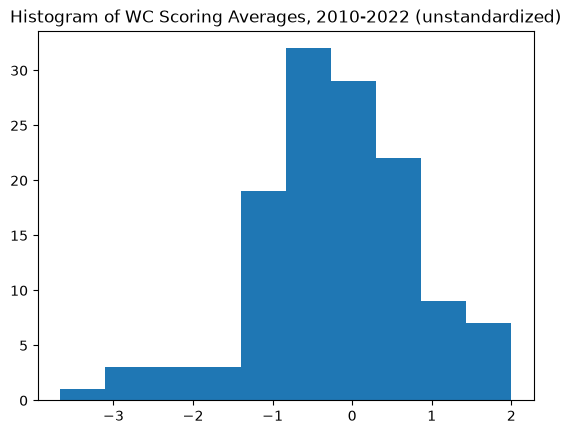

In [5]:
fig, ax = plt.subplots()
ax.hist(unstandardized_Y)
ax.set_title('Histogram of WC Scoring Averages, 2010-2022 (unstandardized)')
plt.show()

### Standardizing the Y vector
Inspecting the Y vector reveals that it has a mean slightly less than -0.2 and a standard deviation of approximately 0.98. That means that standardizing the data by subtracting the mean and dividing by the standard deviation only very slightly changes the values, but it's still best practice for modeling a continuous variable.

In [6]:
Y_mean = np.mean(unstandardized_Y)
Y_std_dev = np.std(unstandardized_Y)
# For simplicity, the standardized Y will be named simply Y
Y = (unstandardized_Y - Y_mean)/Y_std_dev
Y

array([ 0.88406598,  0.81582215, -0.8220296 ,  1.02055362, -0.8220296 ,
       -0.31020093,  0.54284686, -0.48081048, -0.31020093, -0.8220296 ,
        1.81023214,  0.40635921, -0.8220296 , -0.8220296 , -0.13959137,
        0.88406598, -3.55178252, -0.05428659, -0.05428659,  0.93281156,
        0.20162775, -0.48081048,  0.40635921,  1.73711376, -0.13959137,
       -0.31020093,  0.20162775, -0.48081048,  1.07904833,  0.20162775,
        0.20162775,  0.64033804,  0.20162775,  0.64033804, -1.84568694,
        0.81582215,  0.54284686, -0.09084578, -2.52812517,  0.71345642,
        1.8394795 ,  0.81582215, -0.13959137, -0.13959137,  0.20162775,
       -0.48081048,  1.22528509,  2.24894244, -0.13959137, -0.31020093,
       -1.84568694, -0.8220296 , -0.13959137, -1.16324871, -0.8220296 ,
        0.71345642,  1.81023214, -0.05428659, -1.16324871, -0.13959137,
       -0.8220296 ,  0.20162775, -0.05428659, -0.31020093,  1.02055362,
       -1.50446783, -1.16324871,  1.02055362, -0.48081048,  0.20

## Setup part 2: Creating the feature space

This notebook uses two primary features: the nation's FIFA Ranking Points at the time of the final rankings before the tournament began, and a metric calculating how many players on each roster were employed in one of the top 5 European professional leagues (the English Premier League, Spain's La Liga, the German Bundesliga, Italy's Serie A, or France's Ligue One). These features will be analyzed and combined in a variety of models.


### Importing FIFA Rankings Point data

Our historical FIFA Ranking data is pulled from a `csv` downloaded from kaggle, as documented in the `citations.txt`. As with the y-vector above, the data is first assembled into a Python list, then cast into a numpy array, which is visualized, then standardized.

In [7]:
fifa_rankings = pd.read_csv('fifa_ranking-2024-06-20.csv')
rpoints_list = []

rankings_2010 = fifa_rankings[fifa_rankings['rank_date']=='2010-05-26']
for team in team_list_2010:
    for i in range(rankings_2010.shape[0]):
        if rankings_2010.iloc[i, 1].casefold() == team.casefold():
            rpoints_list.append(rankings_2010.iloc[i, 3])

rankings_2014 = fifa_rankings[fifa_rankings['rank_date']=='2014-06-05']
for team in team_list_2014:
    for i in range(rankings_2014.shape[0]):
        if rankings_2014.iloc[i, 1].casefold() == team.casefold():
            rpoints_list.append(rankings_2014.iloc[i, 3])

rankings_2018 = fifa_rankings[fifa_rankings['rank_date']=='2018-06-07']
for team in team_list_2018:
    for i in range(rankings_2018.shape[0]):
        if rankings_2018.iloc[i, 1].casefold() == team.casefold():
            rpoints_list.append(rankings_2018.iloc[i, 3])

rankings_2022 = fifa_rankings[fifa_rankings['rank_date']=='2022-10-06']
for team in team_list_2022:
    for i in range(rankings_2022.shape[0]):
        if rankings_2022.iloc[i, 1].casefold() == team.casefold():
            rpoints_list.append(rankings_2022.iloc[i, 3])

len(rpoints_list)


128

In [8]:
unstandardized_RP = np.array(rpoints_list)
unstandardized_RP

array([ 821.  , 1076.  ,  886.  , 1611.  ,  887.  ,  888.  ,  856.  ,
        767.  , 1068.  , 1044.  , 1082.  ,  800.  ,  964.  ,  734.  ,
       1184.  ,  682.  ,  285.  ,  632.  ,  895.  , 1231.  ,  410.  ,
        883.  ,  820.  , 1249.  ,  947.  ,  777.  ,  860.  ,  392.  ,
       1565.  ,  866.  ,  957.  ,  899.  ,  858.  , 1175.  ,  526.  ,
       1074.  ,  873.  , 1242.  ,  558.  , 1026.  , 1137.  ,  762.  ,
        809.  ,  903.  ,  791.  , 1090.  ,  913.  , 1300.  ,  704.  ,
       1064.  ,  731.  ,  641.  , 1104.  ,  626.  ,  547.  ,  882.  ,
        981.  ,  640.  , 1189.  ,  893.  , 1485.  , 1149.  , 1035.  ,
       1147.  ,  457.  ,  465.  ,  649.  , 1018.  ,  686.  ,  708.  ,
       1274.  , 1126.  , 1198.  ,  718.  , 1241.  ,  908.  , 1125.  ,
       1051.  ,  945.  ,  618.  ,  884.  ,  751.  , 1558.  ,  989.  ,
       1431.  , 1199.  ,  880.  ,  544.  , 1298.  ,  571.  ,  910.  ,
       1051.  ,  986.  ,  521.  , 1183.  ,  838.  , 1439.89, 1728.47,
       1584.38, 1627

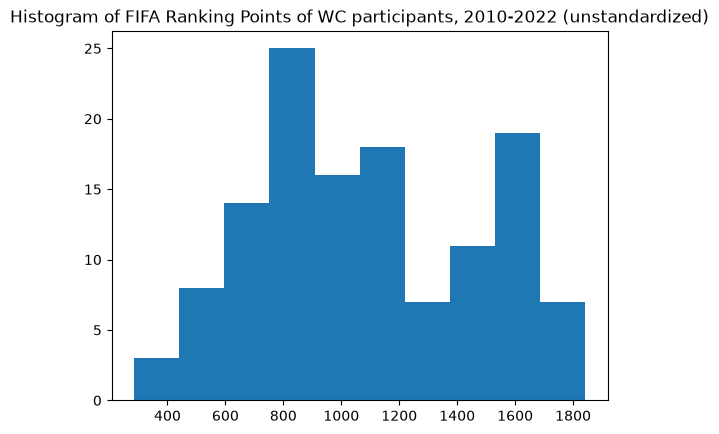

In [9]:
fig, ax = plt.subplots()
ax.hist(unstandardized_RP)
ax.set_title('Histogram of FIFA Ranking Points of WC participants, 2010-2022 (unstandardized)')
plt.show()

In [10]:
RP_mean = np.mean(unstandardized_RP)
RP_std_dev = np.std(unstandardized_RP)
RP = (unstandardized_RP - RP_mean)/RP_std_dev
RP

array([-0.71916185, -0.04361966, -0.54696482,  1.37369435, -0.54431564,
       -0.54166645, -0.62644037, -0.86221784, -0.06481314, -0.12839358,
       -0.02772455, -0.77479474, -0.34032839, -0.94964095,  0.24249233,
       -1.08739857, -2.13912505, -1.21985783, -0.52312216,  0.36700402,
       -1.80797691, -0.55491238, -0.72181104,  0.41468936, -0.38536453,
       -0.83572599, -0.61584363, -1.85566224,  1.25183184, -0.59994852,
       -0.35887268, -0.51252542, -0.621142  ,  0.21864966, -1.50067144,
       -0.04891803, -0.58140423,  0.39614506, -1.41589752, -0.17607891,
        0.11798063, -0.87546377, -0.75095207, -0.50192868, -0.7986374 ,
       -0.00653107, -0.47543683,  0.54979779, -1.0291165 , -0.07540988,
       -0.95758851, -1.19601516,  0.03055752, -1.23575294, -1.44503856,
       -0.55756156, -0.29529224, -1.19866435,  0.25573825, -0.52842053,
        1.03989703,  0.14977085, -0.15223625,  0.14447248, -1.68346521,
       -1.66227173, -1.17482168, -0.19727239, -1.07680183, -1.01

### Aggregating T5League data

Fbref.com has aggregated roster-composition-by-league data easily accessible for the 2022 World Cup, but the data below for 2010, 2014, and 2018 were hand transcribed by examining the fbref page of each individual member of each World Cup roster. For the summer World Cups (2010, 2014, and 2018), the data reflects where a given player played in the season preceding the World Cup--i.e., the 2010 data reflects where players played in the 2009-2010 season. If a player appeared in multiple leagues during that season, they were counted as being a part of the "highest" league they played in, defined as English Premier League > La Liga > Bundesliga > Serie A > Ligue 1 > all other leagues.

As we compiled the data, we learned that World Cup roster sizes expanded in 2022: for the 2010, 2014, and 2018 tournaments, rosters were capped at 23 players; for the 2022 and 2026 tournaments, teams were allowed to roster 26 players. Therefore, the roster numbers below must be scaled by the total number of players on the roster to account for this change.

In [11]:
# These arrays need to be in the same order as the team lists for each respective year
# Data transcribed by hand from fbref.com

EPL_10 = np.array([3, 3, 6, 2, 3, 0, 6, 4, 23, 7, 0, 4, 1, 3, 0, 0,
                    0, 2, 2, 4, 2, 5, 2, 3, 4, 2, 0, 3, 3, 2, 7, 0])
La_Liga_10 = np.array([1, 3, 0, 4, 2, 2, 3, 1, 0, 3, 0, 1, 0, 0, 0, 1,
                        0, 0, 2, 2, 0, 2, 1, 5, 2, 0, 0, 0, 20, 0, 0, 3])
Bundesliga_10 = np.array([3, 1, 0, 2, 3, 1, 2, 2, 0, 1, 23, 3, 2, 0, 0, 1,
                            0, 1, 1, 5, 0, 2, 3, 3, 5, 4, 3, 0, 0, 8, 3, 0])
Serie_A_10 = np.array([1, 6, 1, 8, 1, 2, 0, 4, 0, 0, 0, 3, 2, 2, 23, 1,
                        0, 0, 0, 2, 0, 0, 1, 1, 3, 1, 2, 0, 0, 4, 0, 4])
Ligue_1_10 = np.array([4, 1, 0, 1, 6, 0, 3, 0, 0, 11, 0, 1, 0, 0, 0, 2,
                        0, 1, 0, 0, 0, 3, 0, 0, 0, 1, 3, 0, 0, 2, 1, 1])

EPL_14 = np.array([1, 2, 1, 11, 2, 6, 1, 1, 0, 1, 4, 2, 1, 22, 11, 4,
                    1, 2, 2, 1, 0, 2, 3, 1, 6, 5, 1, 0, 6, 1, 5, 3])
La_Liga_14 = np.array([5, 4, 0, 2, 0, 3, 3, 3, 2, 1, 0, 3, 0, 0, 3, 1,
                        0, 2, 0, 0, 0, 0, 0, 4, 0, 1, 6, 0, 14, 1, 0, 4])
Bundesliga_14 = np.array([0, 1, 1, 2, 6, 2, 2, 0, 2, 1, 4, 4, 1, 0, 0, 16,
                        1, 1, 0, 1, 0, 6, 4, 0, 3, 0, 1, 0, 1, 9, 4, 0])
Serie_A_14 = np.array([2, 7, 0, 1, 2, 3, 0, 4, 7, 0, 1, 3, 0, 0, 1, 2,
                        4, 6, 0, 0, 20, 2, 0, 0, 1, 1, 1, 0, 2, 5, 1, 5])
Ligue_1_14 = np.array([4, 2, 0, 1, 0, 2, 5, 0, 3, 0, 5, 1, 0, 0, 7, 0,
                        5, 0, 0, 0, 3, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1])

EPL_18 = np.array([0, 0, 5, 0, 1, 0, 4, 4, 5, 2, 3, 2, 1, 5, 1, 5,
                    0, 5, 3, 1, 6, 2, 2, 2, 12, 0, 1, 23, 3, 2, 3, 4])
La_Liga_18 = np.array([1, 2, 0, 5, 4, 0, 1, 17, 6, 0, 4, 0, 0, 3, 4, 2,
                        4, 2, 2, 3, 5, 1, 1, 0, 3, 0, 0, 0, 6, 2, 0, 1])
Bundesliga_18 = np.array([0, 0, 0, 0, 1, 0, 1, 1, 2, 1, 0, 1, 0, 4, 3, 1, 
                            0, 3, 15, 2, 0, 10, 3, 1, 2, 0, 0, 0, 1, 6, 3, 1])
Serie_A_18 = np.array([0, 0, 0, 5, 1, 0, 2, 1, 1, 0, 5, 1, 0, 2, 7, 2,
                        1, 4, 1, 1, 3, 5, 4, 1, 1, 0, 0, 0, 2, 1, 7, 3])
Ligue_1_18 = np.array([0, 0, 0, 1, 2, 0, 3, 0, 9, 0, 2, 0, 0, 2, 1, 1,
                        0, 0, 2, 0, 3, 1, 3, 0, 2, 0, 7, 0, 1, 2, 1, 7])

EPL_22 = np.array([0, 25, 6, 6, 5, 7, 1, 5, 2, 4, 5, 7, 5, 3, 10, 12,
                9, 3, 0, 2, 2, 2, 1, 2, 3, 1, 0, 0, 0, 0, 5, 1])
La_Liga_22 = np.array([0, 0, 3, 2, 10, 4, 1, 5, 4, 2, 18, 4, 1, 4, 2, 5,
                    0, 2, 0, 1, 1, 3, 0, 1, 1, 0, 1, 0, 0, 0, 2, 6])
Bundesliga_22 = np.array([0, 1, 1, 2, 1, 6, 0, 6, 1, 20, 1, 3, 7, 0, 2, 0,
                        0, 2, 1, 2, 7, 5, 1, 2, 2, 1, 0, 0, 1, 0, 1, 1])
Serie_A_22 = np.array([0, 0, 2, 2, 4, 2, 2, 3, 2, 0, 0, 2, 2, 3, 2, 3,
                    1, 4, 1, 9, 0, 4, 4, 1, 0, 0, 1, 0, 0, 0, 0, 11])
Ligue_1_22 = np.array([0, 0, 5, 1, 2, 1, 0, 6, 5, 0, 2, 3, 2, 0, 3, 2,
                    2, 0, 2, 2, 3, 1, 4, 0, 1, 0, 0, 0, 2, 1, 5, 0])


In [12]:
EPL_10_scaled = EPL_10/23
La_Liga_10_scaled = La_Liga_10/23
Bundesliga_10_scaled = Bundesliga_10/23
Serie_A_10_scaled = Serie_A_10/23
Ligue_1_10_scaled = Ligue_1_10/23

EPL_14_scaled = EPL_14/23
La_Liga_14_scaled = La_Liga_14/23
Bundesliga_14_scaled = Bundesliga_14/23
Serie_A_14_scaled = Serie_A_14/23
Ligue_1_14_scaled = Ligue_1_14/23

EPL_18_scaled = EPL_18/23
La_Liga_18_scaled = La_Liga_18/23
Bundesliga_18_scaled = Bundesliga_18/23
Serie_A_18_scaled = Serie_A_18/23
Ligue_1_18_scaled = Ligue_1_18/23

EPL_22_scaled = EPL_22/26
La_Liga_22_scaled = La_Liga_22/26
Bundesliga_22_scaled = Bundesliga_22/26
Serie_A_22_scaled = Serie_A_22/26
Ligue_1_22_scaled = Ligue_1_22/26

We'll create individual vectors for each of these five leagues, as well as a combined vector that aggregates the other five into a single sum, to see whether or not models perform better with more granular league data.

In [13]:
unstandardized_EPL = np.concatenate((EPL_10_scaled, EPL_14_scaled, EPL_18_scaled, EPL_22_scaled))
unstandardized_La_Liga = np.concatenate((La_Liga_10_scaled, La_Liga_14_scaled, La_Liga_18_scaled, La_Liga_22_scaled))
unstandardized_Bundesliga = np.concatenate((Bundesliga_10_scaled, Bundesliga_14_scaled, Bundesliga_18_scaled, Bundesliga_22_scaled))
unstandardized_Serie_A = np.concatenate((Serie_A_10_scaled, Serie_A_14_scaled, Serie_A_18_scaled, Serie_A_22_scaled))
unstandardized_Ligue_1 = np.concatenate((Ligue_1_10_scaled, Ligue_1_14_scaled, Ligue_1_18_scaled, Ligue_1_22_scaled))
unstandardized_t5league = unstandardized_EPL + unstandardized_La_Liga + unstandardized_Bundesliga + unstandardized_Serie_A + unstandardized_Ligue_1

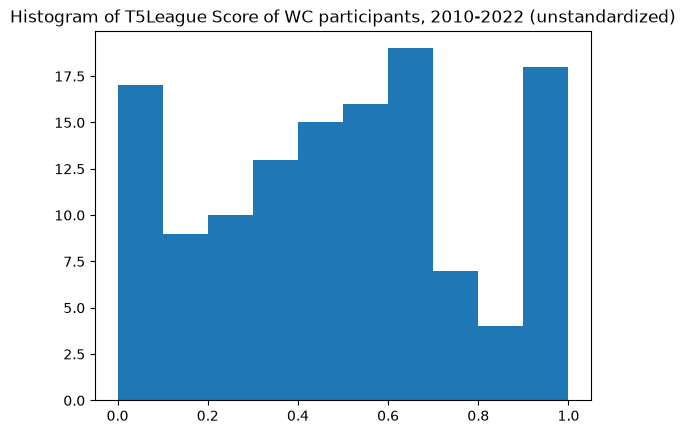

In [14]:
fig, ax = plt.subplots()
ax.hist(unstandardized_t5league)
ax.set_title('Histogram of T5League Score of WC participants, 2010-2022 (unstandardized)')
plt.show()

In [15]:
EPL_mean = np.mean(unstandardized_EPL)
EPL_std_dev = np.std(unstandardized_EPL)
EPL = (unstandardized_EPL - EPL_mean)/EPL_std_dev

La_Liga_mean = np.mean(unstandardized_La_Liga)
La_Liga_std_dev = np.std(unstandardized_La_Liga)
La_Liga = (unstandardized_La_Liga - La_Liga_mean)/La_Liga_std_dev

Bundesliga_mean = np.mean(unstandardized_Bundesliga)
Bundesliga_std_dev = np.std(unstandardized_Bundesliga)
Bundesliga = (unstandardized_Bundesliga - Bundesliga_mean)/Bundesliga_std_dev

Serie_A_mean = np.mean(unstandardized_Serie_A)
Serie_A_std_dev = np.std(unstandardized_Serie_A)
Serie_A = (unstandardized_Serie_A - Serie_A_mean)/Serie_A_std_dev

Ligue_1_mean = np.mean(unstandardized_Ligue_1)
Ligue_1_std_dev = np.std(unstandardized_Ligue_1)
Ligue_1 = (unstandardized_Ligue_1 - Ligue_1_mean)/Ligue_1_std_dev

t5league_mean = np.mean(unstandardized_t5league)
t5league_std_dev = np.std(unstandardized_t5league)
t5league = (unstandardized_t5league - t5league_mean)/t5league_std_dev

### Ordinal Rank Vector

In [16]:
ord_rank_list = []

for team in team_list_2010:
    for i in range(rankings_2010.shape[0]):
        if rankings_2010.iloc[i, 1].casefold() == team.casefold():
            ord_rank_list.append(rankings_2010.iloc[i, 0])

for team in team_list_2014:
    for i in range(rankings_2014.shape[0]):
        if rankings_2014.iloc[i, 1].casefold() == team.casefold():
            ord_rank_list.append(rankings_2014.iloc[i, 0])

for team in team_list_2018:
    for i in range(rankings_2018.shape[0]):
        if rankings_2018.iloc[i, 1].casefold() == team.casefold():
            ord_rank_list.append(rankings_2018.iloc[i, 0])

for team in team_list_2022:
    for i in range(rankings_2022.shape[0]):
        if rankings_2022.iloc[i, 1].casefold() == team.casefold():
            ord_rank_list.append(rankings_2022.iloc[i, 0])

len(ord_rank_list)


128

In [17]:
unstandardized_OR = np.array(ord_rank_list)
unstandardized_OR

array([ 30.,   7.,  20.,   1.,  19.,  18.,  27.,  36.,   8.,   9.,   6.,
        32.,  13.,  38.,   5.,  45., 105.,  47.,  17.,   4.,  78.,  21.,
        31.,   3.,  15.,  34.,  25.,  83.,   2.,  24.,  14.,  16.,  22.,
         5.,  62.,  11.,  21.,   3.,  56.,  14.,   8.,  28.,  23.,  18.,
        26.,  10.,  17.,   2.,  37.,  12.,  33.,  43.,   9.,  46.,  57.,
        20.,  15.,  44.,   4.,  19.,   1.,   6.,  13.,   7.,  70.,  67.,
        45.,  14.,  41.,  37.,   4.,  10.,   7.,  36.,   5.,  22.,  11.,
        12.,  20.,  48.,  23.,  34.,   1.,  15.,   2.,   6.,  24.,  57.,
         3.,  55.,  21.,  12.,  16.,  61.,   8.,  27.,  50.,   5.,  18.,
        16.,   3.,  10.,  13.,   4.,  22.,  11.,   7.,   2.,  15.,  14.,
         9.,   1.,  19.,   8.,  30.,  26.,  24.,  12.,  43.,  28.,  44.,
        20.,  38.,  51.,  41.,  31.,  61.,  21.])

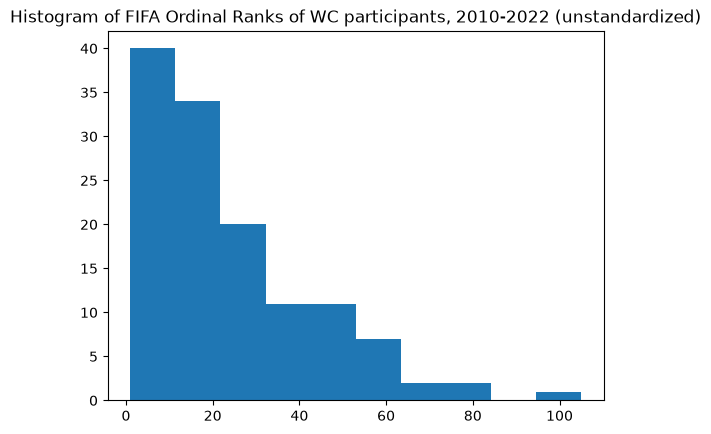

In [18]:
fig, ax = plt.subplots()
ax.hist(unstandardized_OR)
ax.set_title('Histogram of FIFA Ordinal Ranks of WC participants, 2010-2022 (unstandardized)')
plt.show()

In [19]:
OR_mean = np.mean(unstandardized_OR)
OR_std_dev = np.std(unstandardized_OR)
OR = (unstandardized_OR - OR_mean)/OR_std_dev
OR

array([ 0.32150207, -0.85573935, -0.19034202, -1.1628458 , -0.24152643,
       -0.29271084,  0.16794884,  0.62860853, -0.80455494, -0.75337053,
       -0.90692376,  0.42387089, -0.54863289,  0.73097735, -0.95810817,
        1.08926822,  4.16033279,  1.19163703, -0.34389525, -1.00929258,
        2.77835373, -0.13915761,  0.37268648, -1.06047699, -0.44626407,
        0.52623971,  0.06558002,  3.03427578, -1.1116614 ,  0.01439562,
       -0.49744848, -0.39507966, -0.0879732 , -0.95810817,  1.95940318,
       -0.65100171, -0.13915761, -1.06047699,  1.65229672, -0.49744848,
       -0.80455494,  0.21913325, -0.03678879, -0.29271084,  0.11676443,
       -0.70218612, -0.34389525, -1.1116614 ,  0.67979294, -0.5998173 ,
        0.4750553 ,  0.9868994 , -0.75337053,  1.14045263,  1.70348113,
       -0.19034202, -0.44626407,  1.03808381, -1.00929258, -0.24152643,
       -1.1628458 , -0.90692376, -0.54863289, -0.85573935,  2.36887845,
        2.21532523,  1.08926822, -0.49744848,  0.88453058,  0.67

### Creating an Intercept Column

Finally, we'll create an array of 128 1s to serve as an intercept column for regressions, etc.

In [20]:
Ones=np.ones(128)

## Modeling part 1: Linear Regression

### Approach 1: Ranking Points only

In [21]:
X_RP_only = np.transpose(np.vstack((RP, Ones)))
X_RP_only_coefs = np.linalg.lstsq(X_RP_only, Y)
X_RP_only_coefs

(array([2.90707130e-01, 8.86912931e-17]),
 array([117.18263867]),
 np.int32(2),
 array([11.3137085, 11.3137085]))

In [22]:
print(f'For Ranking Points only, the regression residual is {X_RP_only_coefs[1]}')

For Ranking Points only, the regression residual is [117.18263867]


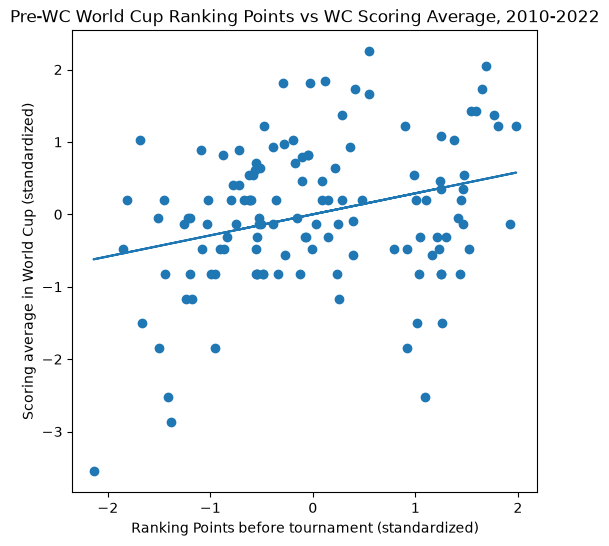

In [23]:
slope, intercept = X_RP_only_coefs[0]
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(RP, Y)
ax.set_xlabel('Ranking Points before tournament (standardized)')
ax.set_ylabel('Scoring average in World Cup (standardized)')
ax.set_title('Pre-WC World Cup Ranking Points vs WC Scoring Average, 2010-2022')
ax.plot(RP, slope*RP + intercept)
plt.show()

### Approach 1a: Ordinal Ranks only

In [24]:
X_OR_only = np.transpose(np.vstack((OR, Ones)))
X_OR_only_coefs = np.linalg.lstsq(X_OR_only, Y)
X_OR_only_coefs

(array([-5.01002888e-01,  5.47798067e-18]),
 array([95.87150154]),
 np.int32(2),
 array([11.3137085, 11.3137085]))

In [25]:
print(f'For Ordinal Rank only, the regression residual is {X_OR_only_coefs[1]}')

For Ordinal Rank only, the regression residual is [95.87150154]


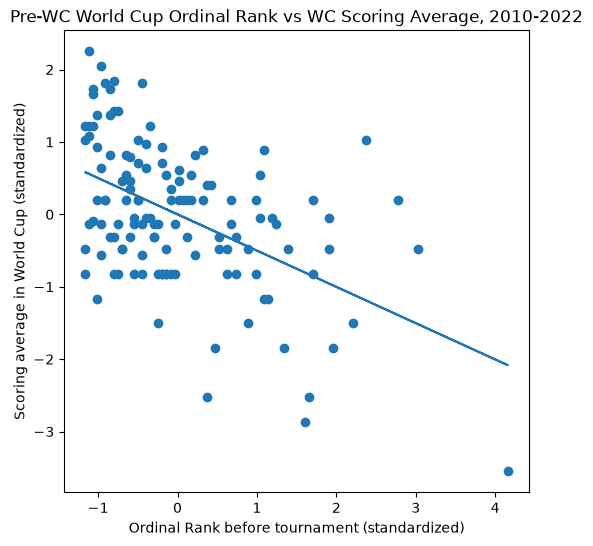

In [26]:
slope, intercept = X_OR_only_coefs[0]
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(OR, Y)
ax.set_xlabel('Ordinal Rank before tournament (standardized)')
ax.set_ylabel('Scoring average in World Cup (standardized)')
ax.set_title('Pre-WC World Cup Ordinal Rank vs WC Scoring Average, 2010-2022')
ax.plot(OR, slope*OR + intercept)
plt.show()

### Approach 2: Roster Composition only
- Approach 2.A: Use aggregated t5league stat only
- Approach 2.B: Use individual league vectors 

In [27]:
# 2.A: Use aggregated t5league stat
X_t5league_only = np.transpose(np.vstack((t5league, Ones)))
X_t5league_only_coefs = np.linalg.lstsq(X_t5league_only, Y)
X_t5league_only_coefs

(array([ 4.75247121e-01, -3.58547036e-17]),
 array([99.08994228]),
 np.int32(2),
 array([11.3137085, 11.3137085]))

In [28]:
print(f'For Roster Composition-only approach A (t5league aggregate), the regression residual is {X_t5league_only_coefs[1]}')

For Roster Composition-only approach A (t5league aggregate), the regression residual is [99.08994228]


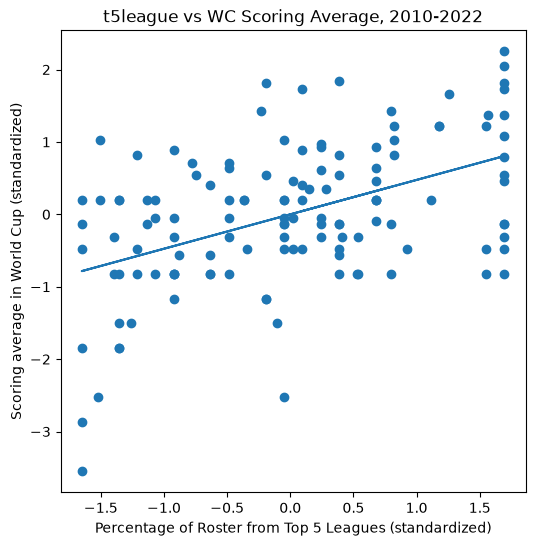

In [29]:
slope, intercept = X_t5league_only_coefs[0]
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(t5league, Y)
ax.set_xlabel('Percentage of Roster from Top 5 Leagues (standardized)')
ax.set_ylabel('Scoring average in World Cup (standardized)')
ax.set_title('t5league vs WC Scoring Average, 2010-2022')
ax.plot(t5league, slope*t5league + intercept)
plt.show()

In [30]:
# 2.A: Use individual league vectors stat
X_individual_leagues_only = np.transpose(np.vstack((EPL, La_Liga, Bundesliga, Serie_A, Ligue_1, Ones)))
X_individual_leagues_only_coefs = np.linalg.lstsq(X_individual_leagues_only, Y)
X_individual_leagues_only_coefs

(array([ 2.74413381e-01,  2.88797443e-01,  2.97742492e-01,  1.72426079e-01,
         6.41660314e-02, -3.20970925e-17]),
 array([97.15648779]),
 np.int32(6),
 array([12.43377597, 12.09322524, 11.3137085 , 11.06947403, 10.74457202,
        10.05862989]))

In [31]:
print(f'For Roster Composition-only approach B (individual league vectors), the regression residual is {X_individual_leagues_only_coefs[1]}')

For Roster Composition-only approach B (individual league vectors), the regression residual is [97.15648779]


### Approach 3: Ranking Points & Roster Composition together
- Approach 3.A: Use aggregated t5league stat
- Approach 3.B: Use individual league vectors

In [32]:
# 3.A: Use aggregated t5league stat
X_t5l_RP = np.transpose(np.vstack((RP, t5league, Ones)))
X_t5l_RP_coefs = np.linalg.lstsq(X_t5l_RP, Y)
X_t5l_RP_coefs

(array([ 1.08444664e-01,  4.29194865e-01, -5.58548345e-17]),
 array([97.85609462]),
 np.int32(3),
 array([13.50394947, 11.3137085 ,  8.58157029]))

In [33]:
print(f'For Ranking Points + Roster Composition approach A (t5league aggregate), the regression residual is {X_t5l_RP_coefs[1]}')

For Ranking Points + Roster Composition approach A (t5league aggregate), the regression residual is [97.85609462]


In [34]:
# 3.B: Use individual league vectors
X_ind_lg_RP = np.transpose(np.vstack((RP, EPL, La_Liga, Bundesliga, Serie_A, Ligue_1, Ones)))
X_ind_lg_RP_coefs = np.linalg.lstsq(X_ind_lg_RP, Y)
X_ind_lg_RP_coefs

(array([ 9.69620299e-02,  2.51865895e-01,  2.57851364e-01,  2.79752380e-01,
         1.53474535e-01,  5.97754110e-02, -2.90617063e-17]),
 array([96.19653524]),
 np.int32(7),
 array([13.48256305, 12.29424776, 11.76615573, 11.3137085 , 11.03776578,
        10.48606409,  8.0523122 ]))

In [35]:
print(f'For Ranking Points + Roster Composition approach B (individual league vectors), the regression residual is {X_ind_lg_RP_coefs[1]}')

For Ranking Points + Roster Composition approach B (individual league vectors), the regression residual is [96.19653524]


### Alternate Approach 3: Substituting Ordinal Rank for Ranking Points

In [36]:
# 3.A: Use aggregated t5league stat
X_t5l_OR = np.transpose(np.vstack((OR, t5league, Ones)))
X_t5l_OR_coefs = np.linalg.lstsq(X_t5l_OR, Y)
X_t5l_OR_coefs

(array([-3.33067811e-01,  2.60671073e-01,  9.35311575e-18]),
 array([90.78385762]),
 np.int32(3),
 array([14.50733916, 11.3137085 ,  6.74811903]))

In [37]:
print(f'For Ordinal Rank + Roster Composition approach A (t5league aggregate), the regression residual is {X_t5l_OR_coefs[1]}')

For Ordinal Rank + Roster Composition approach A (t5league aggregate), the regression residual is [90.78385762]


In [38]:
# 3.B: Use individual league vectors
X_ind_lg_OR = np.transpose(np.vstack((OR, EPL, La_Liga, Bundesliga, Serie_A, Ligue_1, Ones)))
X_ind_lg_OR_coefs = np.linalg.lstsq(X_ind_lg_OR, Y)
X_ind_lg_OR_coefs

(array([-3.33457082e-01,  1.49392317e-01,  1.65465293e-01,  1.96648004e-01,
         4.76410144e-02,  3.70445243e-02, -3.52626950e-17]),
 array([89.15500072]),
 np.int32(7),
 array([14.19967477, 12.35794711, 11.87243614, 11.3137085 , 11.00235967,
        10.58834587,  6.28734068]))

In [39]:
print(f'For Ranking Points + Roster Composition approach B (individual league vectors), the regression residual is {X_ind_lg_OR_coefs[1]}')

For Ranking Points + Roster Composition approach B (individual league vectors), the regression residual is [89.15500072]


In [40]:
model_1_results = {
    "Ranking Points Only": X_RP_only_coefs[1],
    "Ordinal Ranks Only": X_OR_only_coefs[1],
    "t5league Only": X_t5league_only_coefs[1],
    "Individual League Vectors Only": X_individual_leagues_only_coefs[1],
    "Ranking Points + t5league": X_t5l_RP_coefs[1],
    "Ranking Points + Individual League Vectors": X_ind_lg_RP_coefs[1],
    "Ordinal Ranks + t5league": X_t5l_OR_coefs[1],
    "Ordinal Ranks + Individual League Vectors": X_ind_lg_OR_coefs[1]
    }

print("Average Error     Model")
print("-------------     ------------------------------------------")
for model, resid in model_1_results.items():
    print(f"{resid/128}      {model}")


Average Error     Model
-------------     ------------------------------------------
[0.91548936]      Ranking Points Only
[0.74899611]      Ordinal Ranks Only
[0.77414017]      t5league Only
[0.75903506]      Individual League Vectors Only
[0.76450074]      Ranking Points + t5league
[0.75153543]      Ranking Points + Individual League Vectors
[0.70924889]      Ordinal Ranks + t5league
[0.69652344]      Ordinal Ranks + Individual League Vectors


### Revised Conclusion with Ordinal Rank instead of Ranking Points:

- Our intution that the change of scale for ranking points rendered it an unsuitable target for regression proved true. Switching to ordinal rank rather than raw points--which had proved *less* predictive in the initial data exploration of the 2018 and 2022 tournaments--produced a much better result than ranking points across the full four-tournament data set. No longer does our custom t5league metric outperform a rankings-only metric, as the Ordinal Ranks Only model outperformed the t5league Only model.
- Using the individual league vectors instead of t5league closed that gap a bit, but probably not enough to justify the dramatically increased dimensionality.
- However, a promising result is that the t5league metric, when *combined* with ordinal ranks, outperforms either metric alone, and arguably by enough to justify the extra dimension relative to the Ordinal Ranks Only model.
- The Ordinal Ranks + Individual League Vectors approach is technically the best performing one overall, but its miniscule improvement over the aggregated t5league state certainly doesn't merit the increased dimensionality.

In the end, this analysis offers modest evidence in favor of an approach that combines the `t5league` metric with FIFA ordinal ranking, but doesn't suggest that the `t5league` metric on its own is an improvement over FIFA ranking.

### Flawed prior conclusion, for archival purposes:

Conclusion: Assessing Linear Regression-based models
- TOP LINE FINDING: Our 't5league' metric, which aims to gauge team strength by tabulating how many of a roster's players play their club soccer in one of the top 5 European professional leagues, significantly outperformed FIFA Ranking Points in predicting World Cup participants' scoring average when each was used individually as an input for regression.
- Using individual vectors separating the five major leagues (rather than the aggregate t5league metric) slightly reduces the residual further, as does combining roster composition data (either in the form of the aggregate t5league data or as five individual vectors) with ranking points in the X matrix, but the relatively small decrease in residual may not be worth the additional complexity. As we assess our model on the 2026 data, we should look to see whether the raw t5league metric generalizes better than the more complex versions of the model tried here.

### Follow Up: Regressing t5league and Ordinal Rank

How much information is t5league adding that isn't already available in Ordinal Rank?

In [41]:
crosscheck_coefs = np.linalg.lstsq(X_t5league_only, OR)
crosscheck_coefs

(array([-6.44241325e-01,  6.41510768e-17]),
 array([74.87399871]),
 np.int32(2),
 array([11.3137085, 11.3137085]))

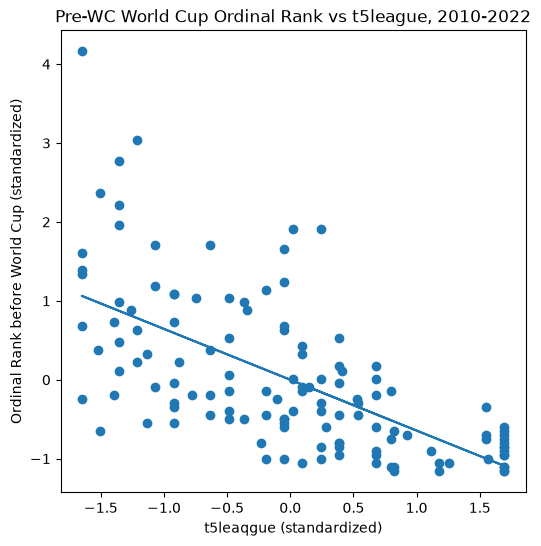

In [42]:
slope, intercept = crosscheck_coefs[0]
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(t5league, OR)
ax.set_xlabel('t5leaqgue (standardized)')
ax.set_ylabel('Ordinal Rank before World Cup (standardized)')
ax.set_title('Pre-WC World Cup Ordinal Rank vs t5league, 2010-2022')
ax.plot(t5league, slope*t5league + intercept)
plt.show()

## Modeling part 2: Non-Linear Regression

During linear regression, the `t5league` metric notably decreased the regression residual relative to using FIFA Ranking Points. Does increasing the degree of the variable lead to better fits--and at a significant enough magnitude to justify the increased complexity? This section will experiment with nonlinear fits of the `t5league` metric.

### Approach 1: t5league^2 without RP

In [43]:
X_t5league_only_deg2 = np.transpose(np.vstack((t5league*t5league, t5league, Ones)))
X_t5league_only_deg2_coefs = np.linalg.lstsq(X_t5league_only_deg2, Y)
X_t5league_only_deg2_coefs

(array([-0.0913662 ,  0.48696472,  0.0913662 ]),
 array([97.96989026]),
 np.int32(3),
 array([18.49520337, 11.3137085 ,  7.08564562]))

In [44]:
print(f'For a second-degree approach with t5league only, the regression residual is {X_t5league_only_deg2_coefs[1]}')

For a second-degree approach with t5league only, the regression residual is [97.96989026]


### Approach 2: t5league^2 + RP

In [45]:
X_t5league_RP_deg2 = np.transpose(np.vstack((t5league*t5league, t5league, RP, Ones)))
X_t5league_RP_deg2_coefs = np.linalg.lstsq(X_t5league_RP_deg2, Y)
X_t5league_RP_deg2_coefs

(array([-0.09613329,  0.43933305,  0.11360357,  0.09613329]),
 array([96.61890671]),
 np.int32(4),
 array([18.52284514, 13.46398048,  8.58525301,  7.08503985]))

In [46]:
print(f'For a second-degree approach with t5league, t5league squared, and ranking points (first degree only), the regression residual is {X_t5league_RP_deg2_coefs[1]}')

For a second-degree approach with t5league, t5league squared, and ranking points (first degree only), the regression residual is [96.61890671]


### Approach 2.a: Subbing in Ordinal Rank in place of Ranking Points, and trying OR squared

In [47]:
X_t5league_OR_deg2 = np.transpose(np.vstack((t5league*t5league, t5league, OR, Ones)))
X_t5league_OR_deg2_coefs = np.linalg.lstsq(X_t5league_OR_deg2, Y)
X_t5league_OR_deg2_coefs

(array([-0.05714237,  0.27500693, -0.32219079,  0.05714237]),
 array([90.35460555]),
 np.int32(4),
 array([18.49596488, 14.49635949,  7.47765179,  6.33391583]))

In [48]:
print(f'For a second-degree approach with t5league, t5league squared, and ordinal rank (first degree only), the regression residual is {X_t5league_OR_deg2_coefs[1]}')

For a second-degree approach with t5league, t5league squared, and ordinal rank (first degree only), the regression residual is [90.35460555]


In [49]:
X_t5league_OR_deg2_coefs[1]/128

array([0.70589536])

In [50]:
X_t5league_OR_deg2_variation = np.transpose(np.vstack((OR*OR, OR, t5league, Ones)))
X_t5league_OR_deg2_variation_coefs = np.linalg.lstsq(X_t5league_OR_deg2_variation, Y)
X_t5league_OR_deg2_variation_coefs

(array([-0.02365342, -0.29209432,  0.27560866,  0.02365342]),
 array([90.64545088]),
 np.int32(4),
 array([26.81718109, 13.33819387,  9.53669238,  5.1068388 ]))

In [51]:
print(f'For a second-degree approach with ordinal rank, ordinal rank squared, and t5league (first degree only), the regression residual is {X_t5league_OR_deg2_variation_coefs[1]}')

For a second-degree approach with ordinal rank, ordinal rank squared, and t5league (first degree only), the regression residual is [90.64545088]


### Conclusion: Assessing Nonlinear Regression Models

Introducing a `t5league^2` term hardly reduced the regression residual at all, either with or without ranking points as an input. It therefore seems unlikely that exploring further nonlinear configurations of the data would be fruitful.

7/27 Update: The substitution of ordinal rank in place of ranking points doesn't substantively change this conclusion.

## Approach 3: Neural Network

The fact that the introduction of a second degree `t5league` term above barely decreased our residual suggests that a linear model probably is best for this particular input and outcome combination. But, what if we show off our `tensorflow` skills by needlessly building a neural network?

## Evaluating Every Fitted Model Against Real 2026 World Cup Results

### Why this section exists
This notebook's own conclusion above now favors **Ordinal Rank** (a team's literal FIFA rank position) over both raw Ranking Points and the `t5league` roster-composition metric used alone -- a revision of the notebook's earlier finding. Everything above this point is still **in-sample**: all 8 model variants were fit and evaluated on the same 2010-2022 data. That tells us which model fits the training data best, not which one generalizes.

The 2026 World Cup has since concluded, giving us a real, independent test: `wc_2026_model_input.csv` (in this folder) contains the actual observed outcomes for all 48 participating teams, plus the official FIFA ranking dated 11 June 2026 (both `fifa_rank`, the ordinal position, and `fifa_ranking_points`, matching this notebook's `OR` and `RP` features respectively) and the same top-5-league roster composition data.

### What this section does
It applies all 8 fitted linear regressions above -- not just the one that looks best in-sample -- to the 2026 features, standardized using the **training set's** mean/std (not re-fit on 2026), then scores each against real 2026 results with RMSE and MAE.

In [52]:
wc_2026 = pd.read_csv('wc_2026_model_input.csv')
wc_2026.shape  # (48, n_columns): one row per 2026 World Cup team

(48, 20)

### Building the 2026 feature vectors (standardized using training parameters)

In [53]:
# 2026 roster size cap is 26 players (same as 2022), per the scaling note earlier in this notebook
ROSTER_SIZE_2026 = 26

unstandardized_RP_2026 = wc_2026['fifa_ranking_points'].to_numpy()
unstandardized_OR_2026 = wc_2026['fifa_rank'].to_numpy()  # ordinal FIFA rank position

EPL_2026_scaled = wc_2026['top5_epl_players'].to_numpy() / ROSTER_SIZE_2026
La_Liga_2026_scaled = wc_2026['top5_laliga_players'].to_numpy() / ROSTER_SIZE_2026
Bundesliga_2026_scaled = wc_2026['top5_bundesliga_players'].to_numpy() / ROSTER_SIZE_2026
Serie_A_2026_scaled = wc_2026['top5_seriea_players'].to_numpy() / ROSTER_SIZE_2026
Ligue_1_2026_scaled = wc_2026['top5_ligue1_players'].to_numpy() / ROSTER_SIZE_2026
unstandardized_t5league_2026 = (EPL_2026_scaled + La_Liga_2026_scaled + Bundesliga_2026_scaled
                                 + Serie_A_2026_scaled + Ligue_1_2026_scaled)

# Standardize using the MEAN/STD DEV FROM THE 2010-2022 TRAINING DATA (not re-fit on 2026) --
# this is what keeps the comparison a genuine test of the already-fitted models.
RP_2026 = (unstandardized_RP_2026 - RP_mean) / RP_std_dev
OR_2026 = (unstandardized_OR_2026 - OR_mean) / OR_std_dev
EPL_2026 = (EPL_2026_scaled - EPL_mean) / EPL_std_dev
La_Liga_2026 = (La_Liga_2026_scaled - La_Liga_mean) / La_Liga_std_dev
Bundesliga_2026 = (Bundesliga_2026_scaled - Bundesliga_mean) / Bundesliga_std_dev
Serie_A_2026 = (Serie_A_2026_scaled - Serie_A_mean) / Serie_A_std_dev
Ligue_1_2026 = (Ligue_1_2026_scaled - Ligue_1_mean) / Ligue_1_std_dev
t5league_2026 = (unstandardized_t5league_2026 - t5league_mean) / t5league_std_dev

Ones_2026 = np.ones(len(wc_2026))
Y_2026_actual = wc_2026['mean_scoring_margin'].to_numpy()

### Adding the Neural Network from this notebook to the comparison

The neural network built in `ranking_points_and_t5league_modeling_NN_COPY.ipynb` (using Ordinal Rank + individual leagues, the richest feature set consistent with this notebook's revised conclusion) beat the best linear model in-sample (RMSE 0.555 vs. 0.835). We refit the identical network here (same architecture, same features, same `random_state=0`) and score it on real 2026 results the same way as the 8 linear models above, to check whether that in-sample edge is real signal or overfitting -- the same question asked (and answered) for the Ranking-Points-based network in the project's earlier round of evaluation.

In [54]:
from sklearn.neural_network import MLPRegressor

X_nn_train = np.transpose(np.vstack((OR, EPL, La_Liga, Bundesliga, Serie_A, Ligue_1)))

nn_model = MLPRegressor(
    hidden_layer_sizes=(8,),
    activation='relu',
    solver='lbfgs',
    max_iter=5000,
    random_state=0,
)
nn_model.fit(X_nn_train, Y)

X_nn_2026 = np.transpose(np.vstack((OR_2026, EPL_2026, La_Liga_2026, Bundesliga_2026, Serie_A_2026, Ligue_1_2026)))

### Applying all 8 fitted models -- plus the neural network -- and scoring against actual 2026 results

In [55]:
def predict(X, model_or_coefs):
    # Linear models are stored as (X, coefs) from np.linalg.lstsq; the neural network
    # is stored as (X, a fitted sklearn model) -- dispatch on which one we were given.
    if hasattr(model_or_coefs, 'predict'):
        return model_or_coefs.predict(X)
    return X @ model_or_coefs[0]

def unstandardize_Y(standardized_pred):
    return standardized_pred * Y_std_dev + Y_mean

def rmse(pred, actual):
    return np.sqrt(np.mean((pred - actual) ** 2))

def mae(pred, actual):
    return np.mean(np.abs(pred - actual))

X_RP_only_2026 = np.transpose(np.vstack((RP_2026, Ones_2026)))
X_OR_only_2026 = np.transpose(np.vstack((OR_2026, Ones_2026)))
X_t5league_only_2026 = np.transpose(np.vstack((t5league_2026, Ones_2026)))
X_individual_leagues_only_2026 = np.transpose(np.vstack((EPL_2026, La_Liga_2026, Bundesliga_2026, Serie_A_2026, Ligue_1_2026, Ones_2026)))
X_t5l_RP_2026 = np.transpose(np.vstack((RP_2026, t5league_2026, Ones_2026)))
X_ind_lg_RP_2026 = np.transpose(np.vstack((RP_2026, EPL_2026, La_Liga_2026, Bundesliga_2026, Serie_A_2026, Ligue_1_2026, Ones_2026)))
X_t5l_OR_2026 = np.transpose(np.vstack((OR_2026, t5league_2026, Ones_2026)))
X_ind_lg_OR_2026 = np.transpose(np.vstack((OR_2026, EPL_2026, La_Liga_2026, Bundesliga_2026, Serie_A_2026, Ligue_1_2026, Ones_2026)))

models_2026 = {
    'Ranking Points only': (X_RP_only_2026, X_RP_only_coefs),
    'Ordinal Rank only': (X_OR_only_2026, X_OR_only_coefs),
    't5league only (aggregate)': (X_t5league_only_2026, X_t5league_only_coefs),
    'Individual leagues only': (X_individual_leagues_only_2026, X_individual_leagues_only_coefs),
    'RP + t5league (aggregate)': (X_t5l_RP_2026, X_t5l_RP_coefs),
    'RP + individual leagues': (X_ind_lg_RP_2026, X_ind_lg_RP_coefs),
    'Ordinal Rank + t5league (aggregate)': (X_t5l_OR_2026, X_t5l_OR_coefs),
    'Ordinal Rank + individual leagues': (X_ind_lg_OR_2026, X_ind_lg_OR_coefs),
    'Neural network (Ordinal Rank + individual leagues)': (X_nn_2026, nn_model),
}

results_2026 = []
for name, (X, model_or_coefs) in models_2026.items():
    pred_standardized = predict(X, model_or_coefs)
    pred_actual = unstandardize_Y(pred_standardized)
    results_2026.append({
        'Model': name,
        'RMSE': rmse(pred_actual, Y_2026_actual),
        'MAE': mae(pred_actual, Y_2026_actual),
    })

results_2026_df = pd.DataFrame(results_2026).sort_values('RMSE').reset_index(drop=True)
results_2026_df

,Model,RMSE,MAE
0,Ordinal Rank + t5league (aggregate),0.930832,0.758847
1,Ordinal Rank + individual leagues,0.938745,0.766174
2,Ordinal Rank only,0.972920,0.788608
3,t5league only (aggregate),1.044963,0.836048
4,RP + t5league (aggregate),1.045186,0.808161
5,RP + individual leagues,1.052786,0.816911
6,Individual leagues only,1.053979,0.850361
7,Neural network (Ordinal Rank + individual leag...,1.153125,0.884218
8,Ranking Points only,1.332633,1.009833


### Visualizing predicted vs. actual 2026 scoring margin (best model by RMSE)

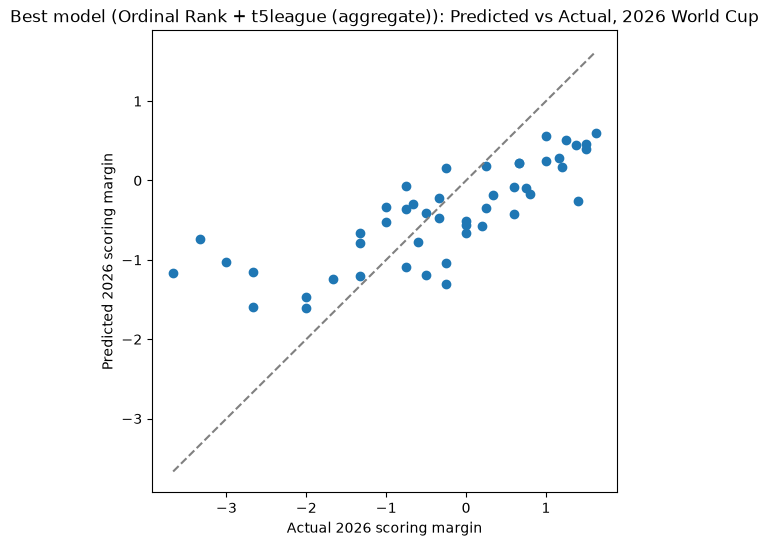

In [56]:
best_model_name = results_2026_df.iloc[0]['Model']
best_X, best_model_or_coefs = models_2026[best_model_name]
best_pred_actual = unstandardize_Y(predict(best_X, best_model_or_coefs))

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(Y_2026_actual, best_pred_actual)
lims = [min(Y_2026_actual.min(), best_pred_actual.min()), max(Y_2026_actual.max(), best_pred_actual.max())]
ax.plot(lims, lims, linestyle='--', color='gray')
ax.set_xlabel('Actual 2026 scoring margin')
ax.set_ylabel('Predicted 2026 scoring margin')
ax.set_title(f'Best model ({best_model_name}): Predicted vs Actual, 2026 World Cup')
plt.show()

### Relating these results back to the project

Five things stand out:

1. **The notebook's revised conclusion holds up out-of-sample -- and by a wider margin than the old conclusion ever did.** `Ordinal Rank + t5league` is the best model on real 2026 results (RMSE 0.931), clearly ahead of every Ranking-Points-based or t5league-only model (all clustered around RMSE 1.04-1.05). `Ordinal Rank only` (0.973) alone beats every one of those too. This is a materially stronger result than what the project's first round of 2026 evaluation found (best RMSE was 1.045, using the old Ranking-Points-based feature set) -- switching to ordinal rank didn't just win in-sample, it produced a genuinely better generalizing model.
2. **Combining metrics is worth it here, unlike in the old analysis.** The old conclusion found that combining roster composition with Ranking Points barely helped. With Ordinal Rank instead, the combination (`Ordinal Rank + t5league`) clearly beats either metric alone out-of-sample -- real evidence that roster composition and FIFA rank capture different, complementary information once rank is represented the right way.
3. **The neural network overfits again, this time even more dramatically.** In-sample RMSE 0.555 vs. 0.835 for the best linear model -- a bigger apparent win than the first neural network attempt. Out-of-sample, it scores 1.153, worse than 7 of the 8 linear models. Two separate neural networks, two confirmed overfitting results -- this is now a pattern, not a one-off.
4. **Ranking Points alone is still the weakest input, in both versions of this analysis.** Whatever else changed, that finding has been stable across the whole project.
5. **This still doesn't answer the proposal's stated evaluation criterion.** Our proposal set the bar as outperforming Nate Silver's "Pele" system's 2026 predictions. That comparison requires Silver's actual predicted scoring margins for 2026, which are not part of this dataset -- his numeric ratings sit behind a paid Silver Bulletin subscription, and even with access, PELE predicts championship/advancement probability, not a scoring margin, so it isn't a free lookup either way. See the note below.

## Attempting the proposal's actual benchmark: Nate Silver's "Pele" system

Our proposal named a specific success criterion: build a model that predicts better than Nate Silver's "Pele" system's 2026 World Cup predictions. We looked into pulling Silver's numbers for a direct RMSE/MAE comparison against the table above, and ran into two real problems worth documenting rather than papering over:

1. **The data is paywalled.** Silver's per-team PELE ratings and match/tournament projections live behind a Silver Bulletin (Substack) paid subscription -- the methodology and headline commentary are free, but the actual numeric table (ratings, projected goals, per-team probabilities) is subscriber-only. We did not sign up for a paid subscription to get around this.
2. **Even with access, it isn't a clean apples-to-apples comparison.** PELE's stated output is *win/advancement/championship probability* per team, not a projected `mean_scoring_margin` (goals scored minus allowed per game) like our target variable. Converting one to the other would require a nontrivial, somewhat arbitrary modeling choice of its own.

**Bottom line for the team:** the proposal's stated evaluation criterion is still open. If someone on the team has (or is willing to get) a Silver Bulletin subscription, pulling PELE's per-team projected goals/ratings and re-running this comparison would close that gap properly. Absent that, the honest claim we can make is narrower than the proposal promised: our best model (Ordinal Rank + roster composition, a linear regression) clearly outperforms FIFA Ranking Points, a simple roster-only metric, and a neural network, on real, out-of-sample 2026 data -- we cannot yet say whether it outperforms Silver's system.